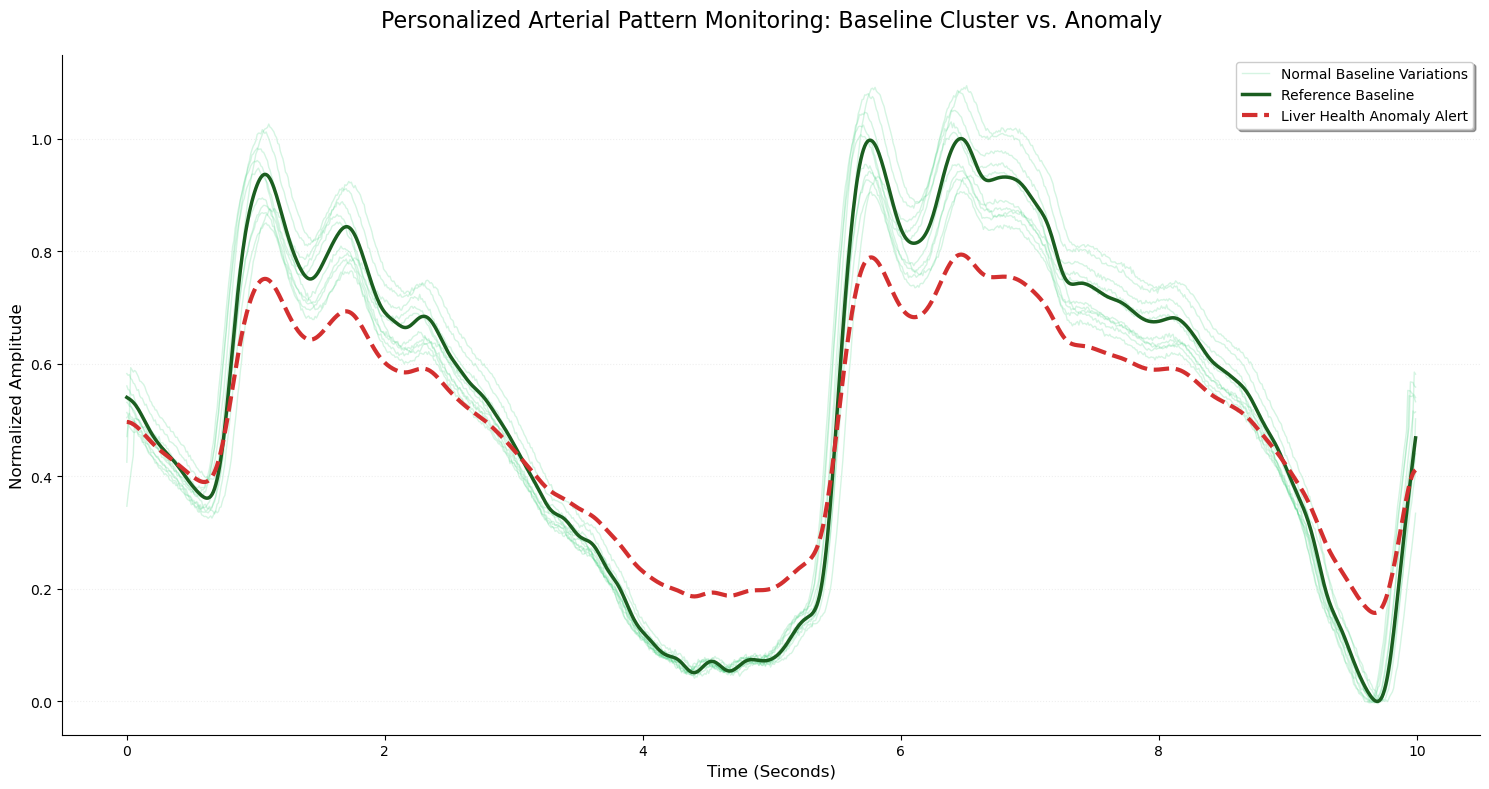

Success: Multi-layered baseline graph generated.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

FILE_PATH = 'S01.csv'
SAMPLING_RATE = 100 

def butter_lowpass_filter(data, cutoff, fs, order=5):
    
    """
    Cleans up the 'shaking' in the sensor data to show a smooth pulse.
    
    """
    # Setting the limit
    # nyq is the maximum speed our sensor can accurately see.
    nyq = 0.5 * fs
    
    # Creating a ratio: tell the computer where to cut the noise.
    # If the signal shakes faster than 'cutoff', we throw it away.
    normal_cutoff = cutoff / nyq
    
    # Designing the 'Eraser': Setup a filter that only keeps slow, smooth waves.
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Erasing the noise: Run the data through our eraser.
    # This keeps our pulse peaks exactly where they actually happened.
    return filtfilt(b, a, data)

def normalize(s):
    return (s - np.min(s)) / (np.max(s) - np.min(s))

try:
    # Load and preprocess actual data
    df = pd.read_csv(FILE_PATH)
    raw_data = df.iloc[:1000, 0].values
    filtered_data = butter_lowpass_filter(raw_data, cutoff=5, fs=SAMPLING_RATE)
    baseline = normalize(filtered_data)
    t = np.arange(len(baseline)) / SAMPLING_RATE

    plt.figure(figsize=(15, 8))

    # Generate Multiple "Normal Daily Variations" (Green Lines)
    # Create several lines that are slightly shifted or scaled from the original.
    for i in range(10): 
        # Apply tiny random shifts in time and amplitude
        shift = np.random.randint(-8, 8)
        gain = np.random.uniform(0.90, 1.10)
        noise = np.random.normal(0, 0.002, len(baseline))
        
        variation = np.roll(baseline, shift) * gain + noise
        
        # Plot with low alpha (transparency) to create a 'Cluster' effect
        label = "Normal Baseline Variations" if i == 0 else ""
        plt.plot(t, variation, color='#2ecc71', alpha=0.2, linewidth=1, label=label)

    # Highlight the "Reference Baseline" (The core pattern)
    plt.plot(t, baseline, color='#1b5e20', linewidth=2.5, label='Reference Baseline')

    # Synthesize the "Pathological Anomaly" (Red Line)
    # This remains distinctly different from the green cluster.
    from scipy.ndimage import gaussian_filter1d
    anomaly = gaussian_filter1d(baseline, sigma=5) * 0.65 + 0.15
    plt.plot(t, anomaly, color='#d32f2f', linewidth=3, linestyle='--', label='Liver Health Anomaly Alert')

    # Final Polish for the Report
    plt.title("Personalized Arterial Pattern Monitoring: Baseline Cluster vs. Anomaly", fontsize=16, pad=20)
    plt.xlabel("Time (Seconds)", fontsize=12)
    plt.ylabel("Normalized Amplitude", fontsize=12)
    
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.grid(True, axis='y', linestyle=':', alpha=0.2)
    
    # Hide top/right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    print("Success: Multi-layered baseline graph generated.")

except Exception as e:
    print(f"Error: {e}")